# Exploratory Data Analysis and Statistical Investigation

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [6]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Capstone-2'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [7]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [8]:
current_dir = os.getcwd()
current_dir

'c:\\'

# Section 1

# Exploratory Data Analysis and Statistical Investigation

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [10]:
df = pd.read_csv("Dataset/cleandata/online_retail_cleaned.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset/cleandata/online_retail_cleaned.csv'

In [ ]:
#df = pd.read_csv("C:\\Capstone-2\\Dataset\\cleandata\\online_retail_cleaned.csv", low_memory=False)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [ ]:
df.shape

(530104, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530104 entries, 0 to 530103
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    530104 non-null  object 
 1   StockCode    530104 non-null  object 
 2   Description  530104 non-null  object 
 3   Quantity     530104 non-null  int64  
 4   InvoiceDate  530104 non-null  object 
 5   UnitPrice    530104 non-null  float64
 6   CustomerID   530104 non-null  int64  
 7   Country      530104 non-null  object 
 8   TotalAmount  530104 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 36.4+ MB


## Dataset Structure

The dataset contains transactional retail information including purchase quantities, pricing information, customer identifiers, and transaction timestamps. The dataset includes both numerical and categorical variables, making it suitable for exploratory analysis and predictive modelling.

The InvoiceDate column was converted into a datetime format to support time-based analysis such as monthly sales trends and seasonal purchasing behaviour.

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalAmount
count,530104.000000,530104.000000,530104.000000,530104.000000
mean,10.542037,3.907625,15292.571875,20.121871
std,155.524124,35.915681,1484.197955,270.356743
min,1.000000,0.001000,12346.000000,0.001000
25%,1.000000,1.250000,14383.000000,3.750000
50%,3.000000,2.080000,15287.000000,9.900000
75%,10.000000,4.130000,16265.000000,17.700000
max,80995.000000,13541.330000,18287.000000,168469.600000


## Statistical Interpretation of the Dataset

The descriptive statistics provide insight into customer purchasing behaviour and transaction patterns within the retail dataset.

The average quantity purchased per transaction is approximately 10.54 items, while the median quantity is 3 items. The large difference between the mean and median suggests the presence of extreme values or outliers, where a small number of transactions involve unusually large purchase quantities.

The standard deviation for Quantity is 155.52, indicating a high level of variability in customer purchasing behaviour. This suggests that transaction sizes vary significantly across customers.

Similarly, the TotalAmount feature has an average transaction value of 20.12, while the maximum transaction exceeds 168,000. This substantial difference between the average and maximum values indicates the existence of high-value outlier transactions that may influence predictive modelling results.

The UnitPrice variable also demonstrates significant variation, with prices ranging from 0.001 to 13,541.33. The high standard deviation of 35.92 further supports the presence of dispersion within pricing data.

The quartile values show that 75% of transactions have a TotalAmount below 17.70, meaning most purchases are relatively low-value transactions. This indicates the dataset may be positively skewed, where the majority of sales are smaller purchases with a limited number of exceptionally large transactions.

These statistical measures are important because they help identify patterns, variability, and anomalies within the dataset before applying machine learning models or conducting further analysis.

In [ ]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [ ]:
df.duplicated().sum()

5226

## Data Cleaning

Missing values and duplicate records were checked to improve data quality and ensure analytical reliability. Duplicate rows were removed to prevent repeated transactions from biasing statistical analysis and machine learning results.

In [ ]:
df = df.drop_duplicates()

A total of duplicate rows were identified and removed from the dataset. This preprocessing step improves dataset consistency and reduces the risk of distorted analytical outcomes.

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

Text(0.5, 1.0, 'Quantity Distribution')

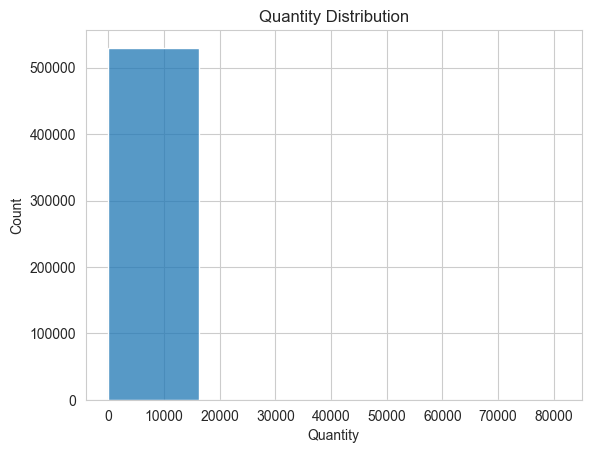

In [13]:
sns.histplot(df['Quantity'], bins=5)
plt.title("Quantity Distribution")

## Quantity Distribution:

The histogram shows that most transactions involve small purchase quantities, while a limited number of transactions involve significantly larger quantities. This suggests the data is positively skewed and contains potential outliers.

Text(0.5, 1.0, 'Total Purchase Amount')

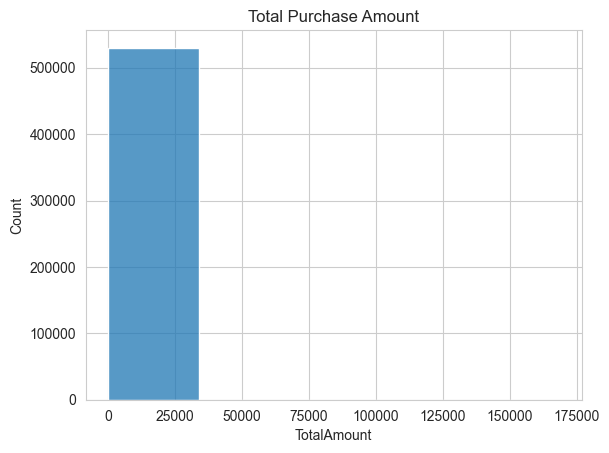

In [14]:
sns.histplot(df['TotalAmount'], bins=5)
plt.title("Total Purchase Amount")

## Total Purchase amount:

The distribution of total purchase amounts demonstrates that most customer transactions are lower-value purchases, while a smaller number of transactions contain significantly higher spending values.This suggests that customer purchasing behaviour is highly variable and positively skewed. The existence of high-value outliers may represent bulk orders or unusually large transactions.

Understanding transaction value distribution is important because extreme spending patterns may impact predictive modelling and statistical analysis.


Text(0.5, 1.0, 'Unit Price Distribution')

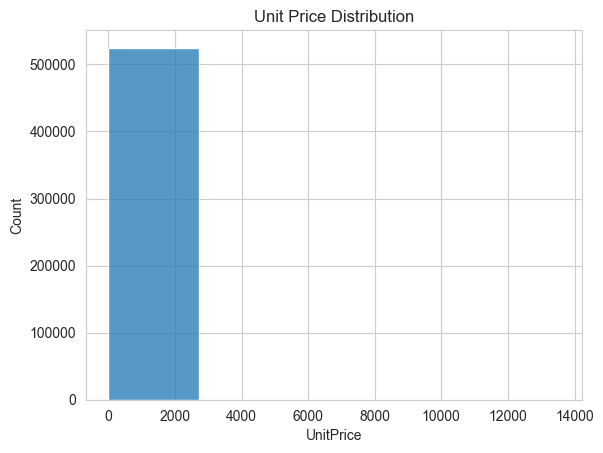

In [36]:
sns.histplot(df['UnitPrice'], bins=5)
plt.title("Unit Price Distribution")

## Unit Price Distribution:

The unit price distribution indicates that the majority of products are sold at relatively low prices, while a limited number of products have exceptionally high unit prices. The distribution appears positively skewed, suggesting that lower-priced products dominate the dataset. The presence of higher-priced outliers may influence average pricing statistics and affect the spread of the data.

This analysis helps identify pricing variability within the retail dataset and supports further investigation into customer purchasing behaviour.

---

# Outliers

<Axes: xlabel='TotalAmount'>

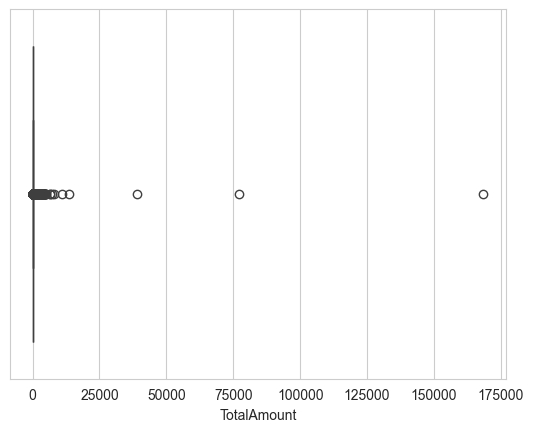

In [37]:
sns.boxplot(x=df['TotalAmount'])

<Axes: xlabel='Quantity'>

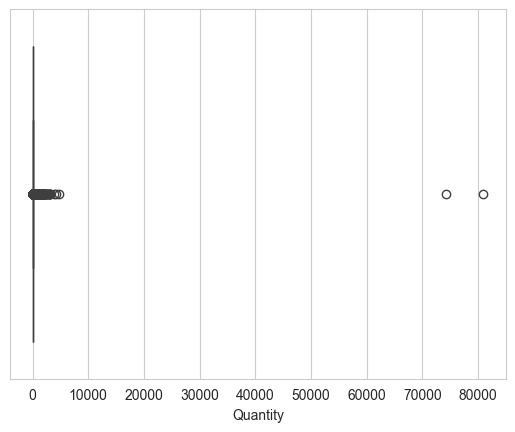

In [38]:
sns.boxplot(x=df['Quantity'])

## Outlier Analysis

The boxplots indicate the presence of several extreme values within the dataset, particularly in TotalAmount and Quantity. These outliers may represent unusually large retail transactions or potential anomalies.

Identifying outliers is important because they can significantly influence statistical measures such as the mean and may affect machine learning model performance.

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [34]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)